# Rice Variety Classification - End-to-End Pipeline

This notebook runs the entire pipeline for the Rice Variety Classification project.

## §0 - Environment Setup
Run this section to prepare the environment (e.g., clone the repository and install requirements if running on Google Colab).


In [3]:
import os
import sys

if 'google.colab' in sys.modules:
    # Replace with your actual GitHub repository URL
    REPO_URL = "https://github.com/powerofdarkine/riceclassifier.git"
    
    if not os.path.exists('riceclassifier'):
        !git clone {REPO_URL} riceclassifier
    
    os.chdir('riceclassifier')
    
    !pip install -q xgboost scikit-learn pandas matplotlib seaborn

sys.path.append(os.path.abspath('.'))


## §1 - Dataset Download & Preparation
Download the ARUZZ225K dataset from Mendeley (Original.zip) and extract it.


In [4]:
import os
import urllib.request
import zipfile

DATA_DIR = "data"
ORIGINAL_DIR = os.path.join(DATA_DIR, "Original")

# Create data directory
os.makedirs(DATA_DIR, exist_ok=True)

TARGET_FILE = "Original.zip"
DOWNLOAD_URL = "https://data.mendeley.com/public-files/datasets/3mn9843tz2/files/14beed89-e936-43f3-ac6a-55ef732f5245/file_downloaded"

zip_path = os.path.join(DATA_DIR, TARGET_FILE)

def make_request(url):
    return urllib.request.Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0 (compatible; riceclassifier/1.0)",
            "Accept": "*/*",
        },
    )

def download_file(url, destination):
    temp_destination = destination + ".part"
    if os.path.exists(temp_destination):
        os.remove(temp_destination)

    with urllib.request.urlopen(make_request(url), timeout=120) as response:
        total_size = int(response.headers.get("Content-Length", 0))
        downloaded = 0
        last_reported = 0

        with open(temp_destination, "wb") as output_file:
            while True:
                chunk = response.read(1024 * 1024)
                if not chunk:
                    break
                output_file.write(chunk)
                downloaded += len(chunk)

                if downloaded - last_reported >= 50 * 1024 * 1024:
                    if total_size:
                        print(f"Downloaded {downloaded / (1024 ** 2):.1f} MB / {total_size / (1024 ** 2):.1f} MB")
                    else:
                        print(f"Downloaded {downloaded / (1024 ** 2):.1f} MB")
                    last_reported = downloaded

    os.replace(temp_destination, destination)

def safe_extract(zip_file, destination):
    destination_abs = os.path.abspath(destination)
    for member in zip_file.infolist():
        member_path = os.path.abspath(os.path.join(destination, member.filename))
        if not member_path.startswith(destination_abs + os.sep) and member_path != destination_abs:
            raise RuntimeError(f"Unsafe path in zip file: {member.filename}")
    zip_file.extractall(destination)

if not os.path.exists(ORIGINAL_DIR):
    if os.path.exists(zip_path) and not zipfile.is_zipfile(zip_path):
        print(f"Existing {zip_path} is not a valid zip file. Re-downloading it...")
        os.remove(zip_path)

    if not os.path.exists(zip_path):
        print(f"Downloading {TARGET_FILE} from Mendeley: {DOWNLOAD_URL}")
        print("Downloading dataset from Mendeley. Please wait, this might take a few minutes...")
        download_file(DOWNLOAD_URL, zip_path)
        print("Download complete.")
    
    if os.path.exists(zip_path):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            safe_extract(zip_ref, DATA_DIR)
        print("Extraction complete.")
else:
    print("Dataset already downloaded and extracted.")


Downloaded 50.0 MB / 254.6 MB
Downloaded 100.0 MB / 254.6 MB
Downloaded 150.0 MB / 254.6 MB
Downloaded 200.0 MB / 254.6 MB
Downloaded 250.0 MB / 254.6 MB
Download complete.
Extracting dataset...
Extraction complete.


## §2 - Exploratory Data Analysis (EDA)
The following cells contain the EDA pipeline.

# EDA

In [3]:
%pip install opencv-python



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 488.3 kB/s  0:01:30 eta 0:00:010:00:03
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
TARGET_SIZE = (224, 224)

DATASET_PATH = Path('data/Original')

def get_class_distribution(base_path):
    """
    Scans the base directory, treating each subfolder as a class,
    and counts the number of image files within each.
    """
    class_counts = {}
    total_samples = 0

    if not base_path.exists():
        print(f"Error: The path {base_path} could not be found.")
        return None, 0

    for class_dir in base_path.iterdir():
        if class_dir.is_dir():
            class_name = class_dir.name

            # Count valid image files in the subfolder
            count = sum(1 for f in class_dir.glob('*.*') if f.suffix.lower() in ['.jpg', '.png', '.jpeg'])

            class_counts[class_name] = count
            total_samples += count

    # Convert pandas DataFrame
    df_counts = pd.DataFrame(list(class_counts.items()), columns=['Rice Type', 'Sample Count'])

    # Sort the dataframe from highest to lowest
    df_counts = df_counts.sort_values(by='Sample Count', ascending=False).reset_index(drop=True)

    return df_counts, total_samples

# ==========================================
# Execution
# ==========================================
distribution_df, total_images = get_class_distribution(DATASET_PATH)

if distribution_df is not None:
    print(f"Total Samples (All Types Combined): {total_images}")
    print(f"Total Unique Rice Types: {len(distribution_df)}")
    print("\n--- Distribution per Rice Type ---")
    display(distribution_df)

Total Samples (All Types Combined): 4730
Total Unique Rice Types: 20

--- Distribution per Rice Type ---


,Rice Type,Sample Count
0,12_Gutisharna,256
1,9_Bashful,252
2,18_Amon,250
3,15_Katari_Polao,242
4,13_Red_Cargo,240
5,19_Shorna5,238
6,17_Chinigura_Polao,237
7,4_Shampakatari,234
8,8_Paijam,234
9,5_Katarivog,233


1 Dataset Indexing

In [5]:
def index_dataset(base_path):
    """Indexes all images and their corresponding class labels from the directory structure."""
    dataset = []
    if not base_path.exists():
        return pd.DataFrame()

    for class_dir in base_path.iterdir():
        if class_dir.is_dir():
            label = class_dir.name
            for img_path in class_dir.glob('*.*'):
                if img_path.suffix.lower() in ['.jpg', '.png', '.jpeg']:
                    dataset.append({'image_path': str(img_path), 'label': label})

    return pd.DataFrame(dataset)

# Execute Indexing
dataset_index = index_dataset(DATASET_PATH)

if not dataset_index.empty:
    print(f"Indexing Complete: Found {len(dataset_index)} images across {dataset_index['label'].nunique()} classes.")
    print("\n--- Dataset Index Information ---")
    dataset_index.info()
else:
    print("System Error: The specified DATASET_PATH could not be resolved.")

Indexing Complete: Found 4730 images across 20 classes.

--- Dataset Index Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4730 entries, 0 to 4729
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  4730 non-null   object
 1   label       4730 non-null   object
dtypes: object(2)
memory usage: 74.0+ KB


Sequential Image Processing & Extraction

In [6]:
def process_and_extract_features(row):
    """Reads the image, standardizes dimensions, and extracts features."""
    path = row['image_path']
    img = cv2.imread(path)
    if img is None:
        return None

    img_resized = cv2.resize(img, TARGET_SIZE)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    # 1. Color Channel Statistics
    r_mean, g_mean, b_mean = np.mean(img_rgb, axis=(0, 1))

    # 2. Sharpness Evaluation
    gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

    # 3. Morphological Feature Extraction
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    area, aspect_ratio = 0.0, 0.0
    if contours:
        main_contour = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(main_contour)
        x, y, w, h = cv2.boundingRect(main_contour)
        aspect_ratio = float(w) / h if h != 0 else 0.0

    return {
        'image_path': path, 'label': row['label'],
        'r_mean': r_mean, 'g_mean': g_mean, 'b_mean': b_mean,
        'blur_score': blur_score, 'grain_area': area, 'aspect_ratio': aspect_ratio
    }

# Execute Extraction
max_samples = 2000
sampled_df = dataset_index.sample(n=min(max_samples, len(dataset_index)), random_state=42)
print(f"Initiating feature extraction for {len(sampled_df)} standardized images...")

results = [process_and_extract_features(row) for _, row in sampled_df.iterrows()]
stats_df = pd.DataFrame([res for res in results if res is not None])

print("\n--- Extracted Features Information ---")
stats_df.info()

Initiating feature extraction for 2000 standardized images...

--- Extracted Features Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   image_path    2000 non-null   object 
 1   label         2000 non-null   object 
 2   r_mean        2000 non-null   float64
 3   g_mean        2000 non-null   float64
 4   b_mean        2000 non-null   float64
 5   blur_score    2000 non-null   float64
 6   grain_area    2000 non-null   float64
 7   aspect_ratio  2000 non-null   float64
dtypes: float64(6), object(2)
memory usage: 125.1+ KB


Visual Analytics

/var/folders/d9/k7fw8c8j5ms0p0t5gnptv3lc0000gn/T/ipykernel_49121/1991052236.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dataset_index, x='label', order=dataset_index['label'].value_counts().index, palette='viridis')


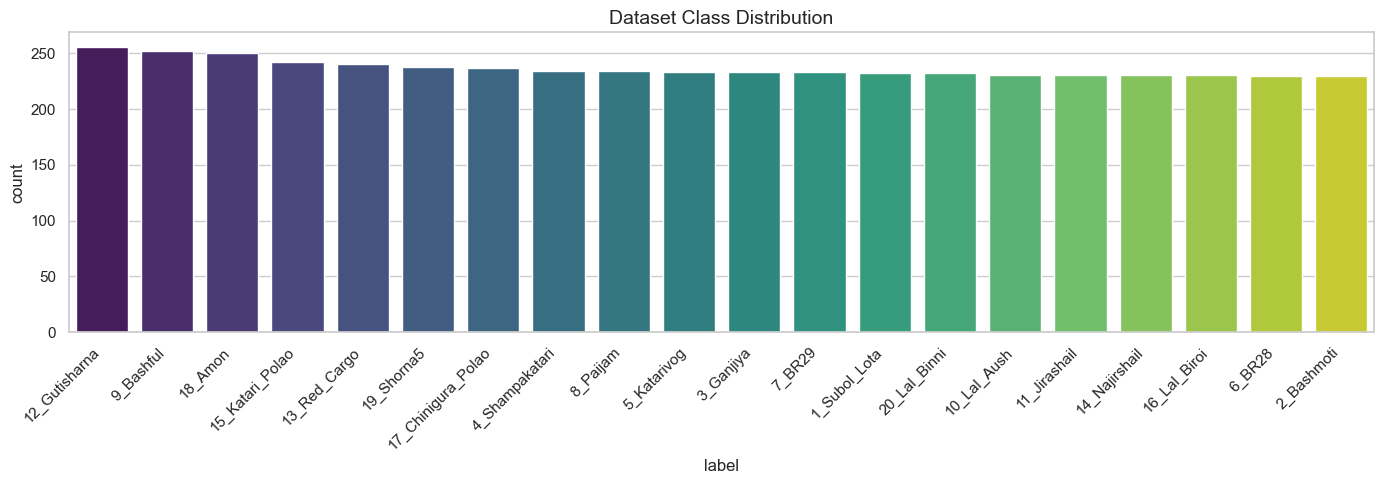

In [7]:
plt.figure(figsize=(14, 5))
sns.countplot(data=dataset_index, x='label', order=dataset_index['label'].value_counts().index, palette='viridis')
plt.title('Dataset Class Distribution', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

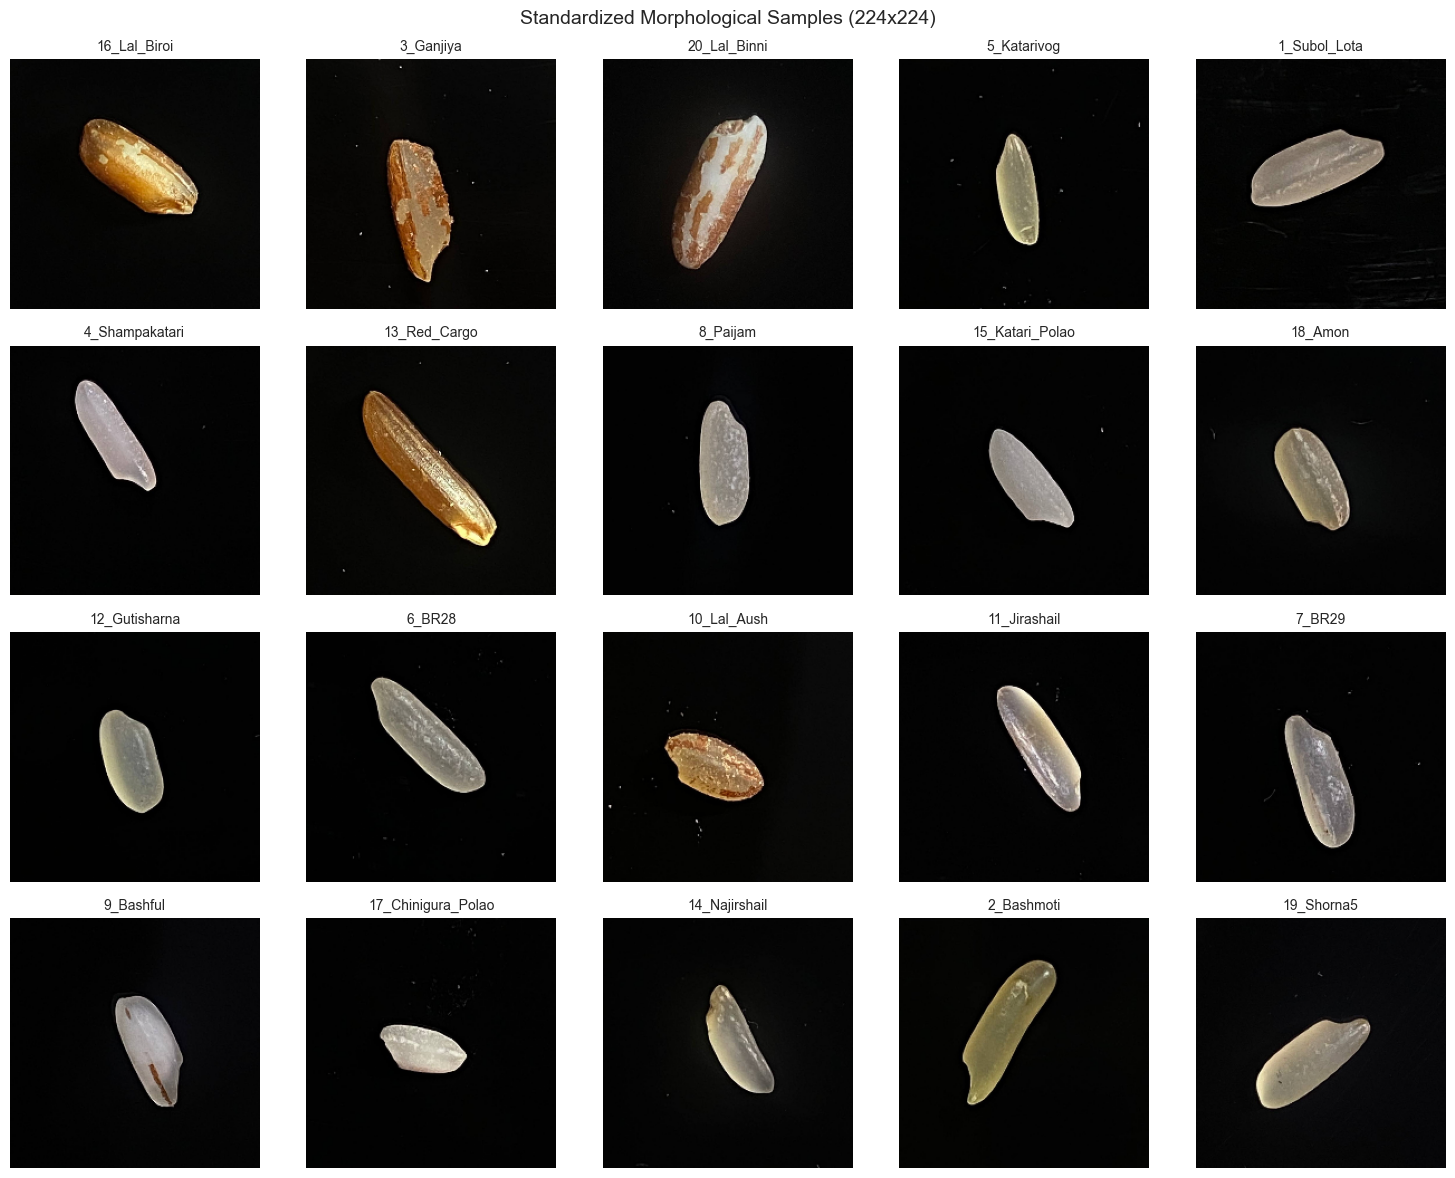

In [8]:
classes = dataset_index['label'].unique()
cols = 5
rows = min(4, (len(classes) + cols - 1) // cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
axes = axes.flatten()

for i, class_name in enumerate(classes[:20]):
    sample_path = random.choice(dataset_index[dataset_index['label'] == class_name]['image_path'].tolist())
    img = cv2.imread(sample_path)
    if img is not None:
        img_resized = cv2.resize(img, TARGET_SIZE)
        img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)
        axes[i].set_title(class_name, fontsize=10)
    axes[i].axis('off')

for j in range(len(classes[:20]), len(axes)):
    axes[j].axis('off')

plt.suptitle("Standardized Morphological Samples (224x224)", fontsize=14)
plt.tight_layout()
plt.show()

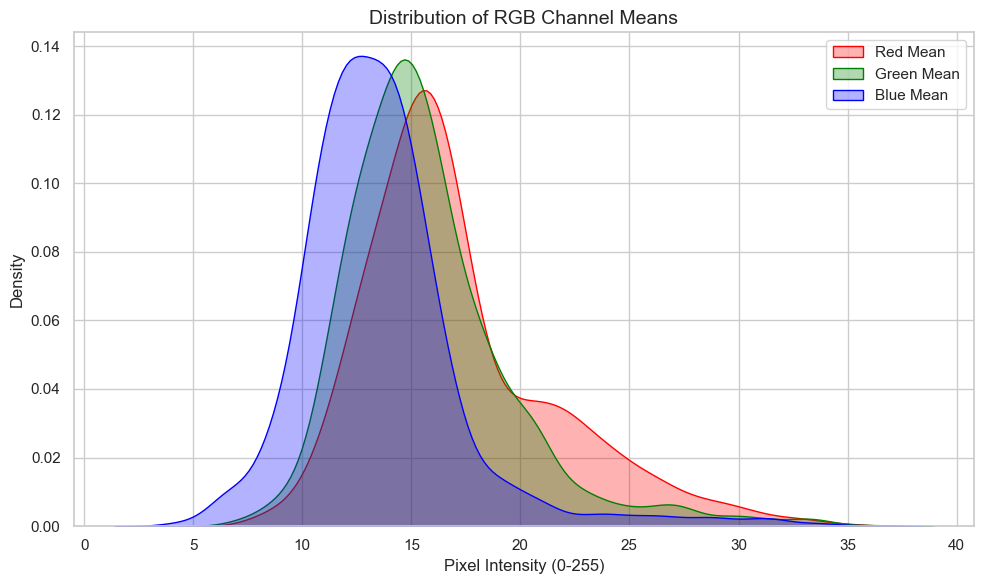

In [9]:
plt.figure(figsize=(10, 6))
sns.kdeplot(stats_df['r_mean'], color='red', label='Red Mean', fill=True, alpha=0.3)
sns.kdeplot(stats_df['g_mean'], color='green', label='Green Mean', fill=True, alpha=0.3)
sns.kdeplot(stats_df['b_mean'], color='blue', label='Blue Mean', fill=True, alpha=0.3)
plt.title('Distribution of RGB Channel Means', fontsize=14)
plt.xlabel('Pixel Intensity (0-255)')
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/d9/k7fw8c8j5ms0p0t5gnptv3lc0000gn/T/ipykernel_49121/196184368.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='label', y='grain_area', data=stats_df, palette='Set2')
/var/folders/d9/k7fw8c8j5ms0p0t5gnptv3lc0000gn/T/ipykernel_49121/196184368.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/var/folders/d9/k7fw8c8j5ms0p0t5gnptv3lc0000gn/T/ipykernel_49121/196184368.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='label', y='aspect_ratio', data=stats_df, palette='Set3')
/var/folders/d9

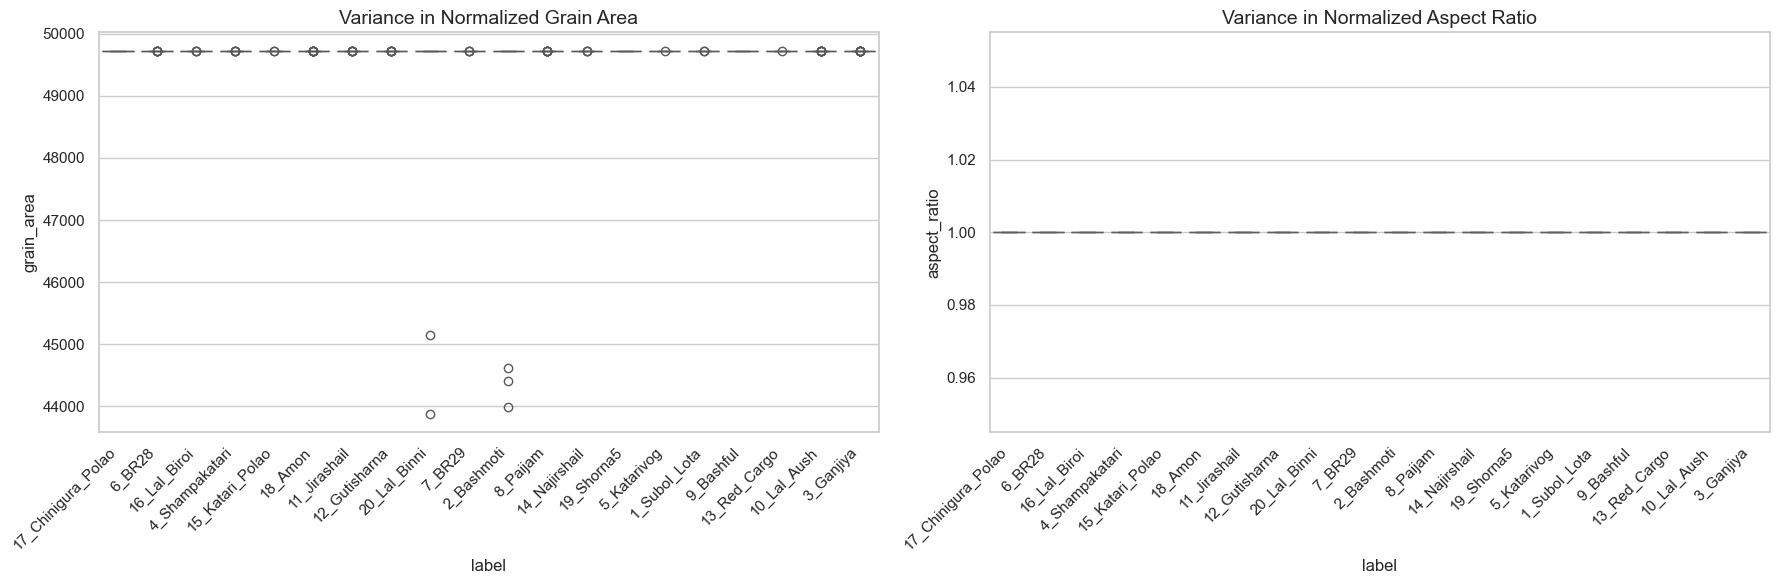

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(ax=axes[0], x='label', y='grain_area', data=stats_df, palette='Set2')
axes[0].set_title('Variance in Normalized Grain Area', fontsize=14)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

sns.boxplot(ax=axes[1], x='label', y='aspect_ratio', data=stats_df, palette='Set3')
axes[1].set_title('Variance in Normalized Aspect Ratio', fontsize=14)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

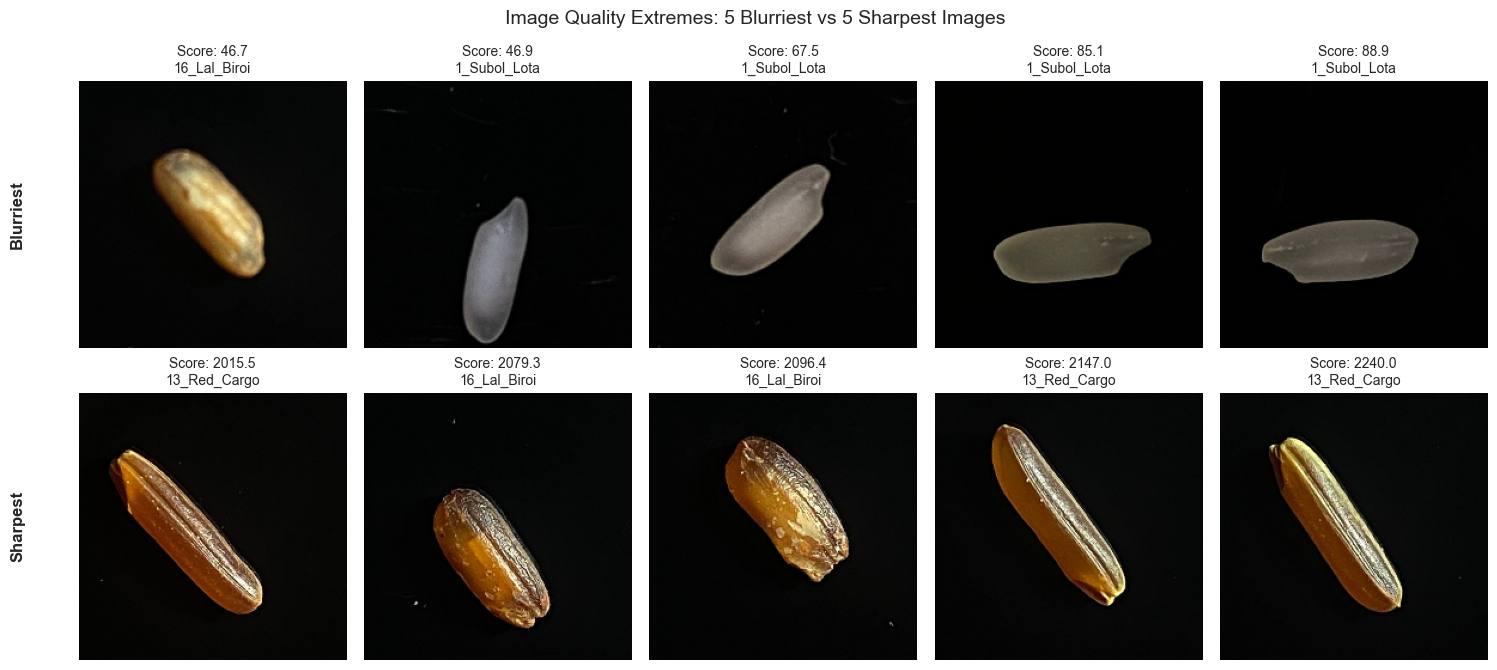

In [11]:
stats_sorted = stats_df.sort_values(by='blur_score')
blurry_samples = stats_sorted.head(5)
sharp_samples = stats_sorted.tail(5)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for i, (_, row) in enumerate(blurry_samples.iterrows()):
    img = cv2.cvtColor(cv2.resize(cv2.imread(row['image_path']), TARGET_SIZE), cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Score: {row['blur_score']:.1f}\n{row['label']}", fontsize=10)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].text(-0.2, 0.5, 'Blurriest', va='center', ha='right', rotation=90, transform=axes[0, i].transAxes, fontsize=12, fontweight='bold')

for i, (_, row) in enumerate(sharp_samples.iterrows()):
    img = cv2.cvtColor(cv2.resize(cv2.imread(row['image_path']), TARGET_SIZE), cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Score: {row['blur_score']:.1f}\n{row['label']}", fontsize=10)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].text(-0.2, 0.5, 'Sharpest', va='center', ha='right', rotation=90, transform=axes[1, i].transAxes, fontsize=12, fontweight='bold')

plt.suptitle("Image Quality Extremes: 5 Blurriest vs 5 Sharpest Images", fontsize=14)
plt.tight_layout()
plt.show()

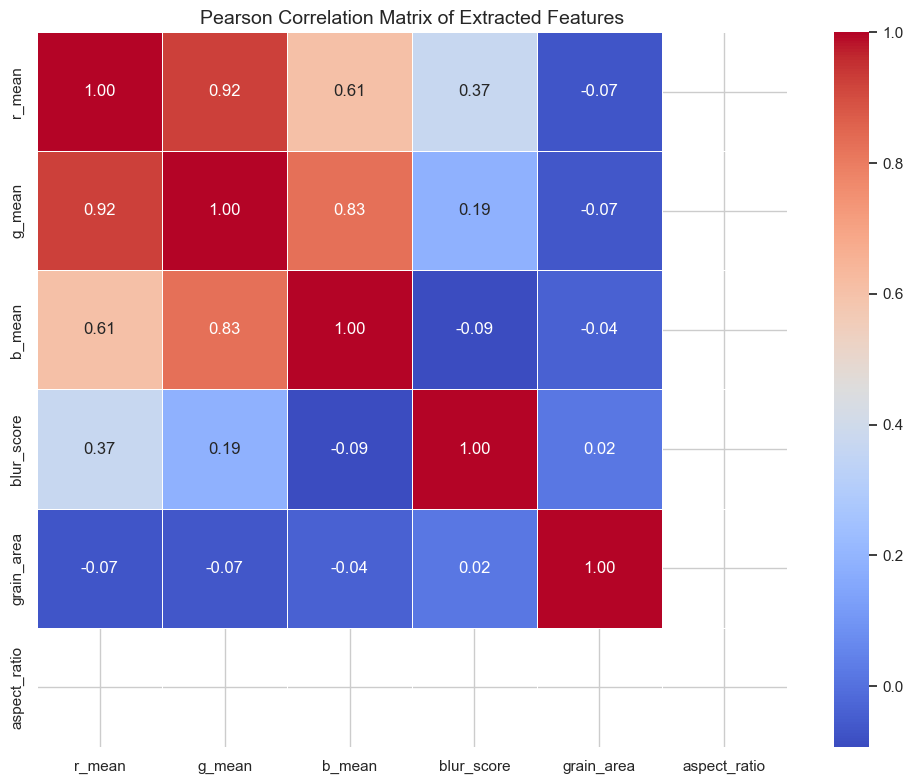

In [12]:
numeric_columns = ['r_mean', 'g_mean', 'b_mean', 'blur_score', 'grain_area', 'aspect_ratio']
correlation_data = stats_df[numeric_columns]

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Pearson Correlation Matrix of Extracted Features', fontsize=14)
plt.tight_layout()
plt.show()

## §3 - Feature Extraction
Extract features using pretrained backbones (VGG16, ResNet18, ViT-B/16) and save them as .npy files.


In [15]:
%pip install torch torchvision torchaudio


  Using cached torchvision-0.26.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (5.5 kB)
  Using cached torchaudio-2.11.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (6.9 kB)
  Using cached torch-2.11.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (29 kB)
Using cached torchvision-0.26.0-cp314-cp314-macosx_12_0_arm64.whl (1.9 MB)
Using cached torch-2.11.0-cp314-cp314-macosx_11_0_arm64.whl (80.6 MB)
Using cached torchaudio-2.11.0-cp314-cp314-macosx_12_0_arm64.whl (679 kB)
  Attempting uninstall: torch━━━━━━━━━━━━━━━━━━━━━━━━━ 0/3 [torchaudio]
    Found existing installation: torch 2.10.0━━━━━ 0/3 [torchaudio]
    Uninstalling torch-2.10.0:━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [torch]
      Successfully uninstalled torch-2.10.05;237m╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [torch]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torchvision]━━━━━━ 2/3 [torchvision]
Note: you may need to restart the kernel to use updated packages.


In [17]:
from modules.data_extractor import run_all_models

# Run extraction (this will save to results/features_all)
# We mock sys.argv if needed, but run_all_models handles it.
import argparse
from pathlib import Path

# The original code uses config.py defaults. We just run it directly.
print("Starting feature extraction...")
run_all_models({"out_root": "features"})


ModuleNotFoundError: No module named 'config'

## §4 - ML Benchmarks
Train classical ML models (LogReg, SVM, KNN, RF, XGBoost) on the extracted features.


In [ ]:
from modules.ml_pipeline import main as run_ml
import sys
import copy

print("Starting ML pipeline benchmark...")

old_argv = copy.copy(sys.argv)
sys.argv = ['ml_pipeline.py', '--device', 'cuda', '--features-root', 'features'] 
run_ml()
sys.argv = old_argv


In [18]:
result_df = pd.read_csv("results/ml_benchmarks/model_comparison_all.csv")
print("\n--- ML Benchmark Results ---")
display(result_df)


--- ML Benchmark Results ---


,architecture,model,device,backend,best_params,tuning_trials,fit_time_sec,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,resnet18_224x224,logreg,cuda,cuda_torch,"{""C"": 3.0}",3,3.7626,0.902748,0.905688,0.902479,0.903412,0.878436,0.882173,0.878717,0.878793
1,resnet18_224x224,linear_svm,cuda,cuda_torch,"{""C"": 3.0}",3,0.7811,0.809725,0.825066,0.808480,0.811335,0.801268,0.814841,0.801291,0.804941
2,resnet18_224x224,knn,cuda,cuda_torch,"{""n_neighbors"": 9, ""weights"": ""distance""}",3,0.0977,0.792812,0.818500,0.791348,0.792714,0.792812,0.813493,0.793296,0.793987
3,resnet18_224x224,random_forest,cuda,cuda_torch,"{""max_depth"": 40, ""max_features"": ""sqrt"", ""n_e...",3,10.3379,0.862579,0.863000,0.861370,0.858892,0.844609,0.844789,0.844101,0.842495
4,resnet18_224x224,xgboost,cuda,cuda_torch,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.1...",3,77.3440,0.871036,0.872658,0.870952,0.870797,0.852008,0.854216,0.851620,0.851866
5,vgg16_224x224,logreg,cuda,cuda_torch,"{""C"": 3.0}",3,0.9121,0.861522,0.860977,0.860660,0.860256,0.853066,0.855310,0.853105,0.852835
6,vgg16_224x224,linear_svm,cuda,cuda_torch,"{""C"": 3.0}",3,0.9014,0.822410,0.831252,0.821487,0.822778,0.827696,0.841227,0.827630,0.831286
7,vgg16_224x224,knn,cuda,cuda_torch,"{""n_neighbors"": 5, ""weights"": ""distance""}",3,0.0665,0.755814,0.759334,0.754819,0.751668,0.734672,0.746159,0.734719,0.733582
8,vgg16_224x224,random_forest,cuda,cuda_torch,"{""max_depth"": 40, ""max_features"": ""sqrt"", ""n_e...",3,9.8374,0.810782,0.810100,0.809684,0.806335,0.798097,0.801870,0.797772,0.796735
9,vgg16_224x224,xgboost,cuda,cuda_torch,"{""colsample_bytree"": 0.9, ""learning_rate"": 0.1...",3,272.1239,0.844609,0.847529,0.843523,0.843830,0.835095,0.839032,0.835159,0.835709


## §5 - Deep Learning Classifier
Train PyTorch Softmax classifier heads on the extracted features.


In [ ]:
from modules.deep_learning import main as run_dl
import sys
import copy

print("Starting DL pipeline training...")

old_argv = copy.copy(sys.argv)
sys.argv = ['deep_learning.py', '--device', 'cuda', '--features-root', 'features'] 
run_dl()
sys.argv = old_argv
